In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import xgboost as xgb
import matplotlib.pyplot as plt
import gpplot as gpp
from rs3.seq import predict_seq
import random
from zipfile import ZipFile
import scipy
from statsmodels.stats.multitest import multipletests
gpp.set_aesthetics(context = 'paper')

In [2]:
sgrna_info = pd.read_excel('../../Data/externalData/hCRISPRiv2/horlbeck_etal_2016_hCRISPRiv2.xlsx',sheet_name = 0)
sgrna_info = sgrna_info[9:].copy()
sgrna_info

,sgID,gene,transcript,protospacer sequence,selection rank,predicted score,empirical score,off-target stringency,CRISPRi-v2.1 predicted score,Sublibrary,Sublibrary half
9,A1BG_-_58858788.23-P1,A1BG,P1,GGGGCACCCAGGAGCGGTAG,2,0.901176,NaN,0,0.782793,h3,Top5
10,A1BG_+_58858964.23-P1,A1BG,P1,GCTCCGGGCGACGTGGAGTG,3,0.836188,NaN,0,0.870837,h3,Top5
11,A1BG_-_58858630.23-P1,A1BG,P1,GAACCAGGGGTGCCCAAGGG,4,0.827551,NaN,0,0.590668,h3,Top5
12,A1BG_+_58858549.23-P1,A1BG,P1,GGCGAGGAACCGCCCAGCAA,5,0.775395,NaN,0,0.49228,h3,Top5
13,A1BG_-_58858950.23-P1,A1BG,P1,GGCAGCGCAGGACGGCATCT,6,0.730457,NaN,0,0.706643,h3,Supp5
...,...,...,...,...,...,...,...,...,...,...,...
209073,non-targeting_03785,negative_control,na,GCTACTCCGCCCCGCGGGAG,NaN,NaN,NaN,0,NaN,h7,Supp5
209074,non-targeting_03786,negative_control,na,GTGGCCGTTCATGGGACCGG,NaN,NaN,NaN,0,NaN,h7,Supp5
209075,non-targeting_03787,negative_control,na,GAACTCTGTAGAAGGGACCG,NaN,NaN,NaN,0,NaN,h7,Supp5
209076,non-targeting_03788,negative_control,na,GCTCGACAGCGACTGAAGAG,NaN,NaN,NaN,0,NaN,h7,Supp5


In [3]:
#read in Set B reads, concatenate Set A and Set B
reads_df = pd.read_excel('../../Data/externalData/hCRISPRiv2/hCRISPRiv2_reads.xlsx',sheet_name = 0)
reads_df.columns = reads_df.iloc[0]
reads_df = reads_df.drop(0,axis=0)
reads_df = reads_df.rename(columns = {'sgId':'sgID'})
reads_df

,sgID,"T0, Rep1","Endpoint, Rep1","T0, Rep2","Endpoint, Rep2","gamma, Rep1","gamma, Rep2","gamma, ave_Rep1_Rep2"
1,A1BG_+_58858549.23-P1,64,37,43,32,-0.063878,NaN,NaN
2,A1BG_+_58858791.23-P1,709,750,838,667,0.0131,0.007153,0.010127
3,A1BG_+_58858964.23-P1,213,271,291,155,0.036621,-0.049368,-0.006374
4,A1BG_+_58864367.23-P2,900,758,830,563,-0.01594,-0.01535,-0.015645
5,A1BG_+_58864705.23-P2,580,685,785,639,0.027137,0.010312,0.018724
...,...,...,...,...,...,...,...,...
209066,non-targeting_03785,724,765,754,657,0.012956,0.01989,0.016423
209067,non-targeting_03786,609,650,679,559,0.014239,0.011903,0.013071
209068,non-targeting_03787,1346,1118,1493,931,-0.017709,-0.027189,-0.022449
209069,non-targeting_03788,259,265,268,203,0.008855,0.00018,0.004518


In [4]:
reads_df = reads_df[['sgID','T0, Rep1','T0, Rep2','Endpoint, Rep1','Endpoint, Rep2']].merge(sgrna_info[['sgID','protospacer sequence','gene']],
                                                                                            on = 'sgID', how = 'inner')
reads_df

,sgID,"T0, Rep1","T0, Rep2","Endpoint, Rep1","Endpoint, Rep2",protospacer sequence,gene
0,A1BG_+_58858549.23-P1,64,43,37,32,GGCGAGGAACCGCCCAGCAA,A1BG
1,A1BG_+_58858791.23-P1,709,838,750,667,GCCAGCACGCCGGCAACTAC,A1BG
2,A1BG_+_58858964.23-P1,213,291,271,155,GCTCCGGGCGACGTGGAGTG,A1BG
3,A1BG_+_58864367.23-P2,900,830,758,563,GTGCTGACGGGTGACACCCA,A1BG
4,A1BG_+_58864705.23-P2,580,785,685,639,GGGGAACAGGAGCCTTACGG,A1BG
...,...,...,...,...,...,...,...
209064,non-targeting_03785,724,754,765,657,GCTACTCCGCCCCGCGGGAG,negative_control
209065,non-targeting_03786,609,679,650,559,GTGGCCGTTCATGGGACCGG,negative_control
209066,non-targeting_03787,1346,1493,1118,931,GAACTCTGTAGAAGGGACCG,negative_control
209067,non-targeting_03788,259,268,265,203,GCTCGACAGCGACTGAAGAG,negative_control


In [68]:
#read in expanded CRISPick run
zip_file = ZipFile('../../Data/CRISPickRuns/expanded-window-rs3i-sgrna-designs.txt.zip')
expanded_rs3i_designs = pd.read_table(zip_file.open('expanded-window-rs3i-sgrna-designs.txt'))
expanded_rs3i_designs

,Input,Quota,Target Taxon,Target Gene ID,Target Gene Symbol,Target Alias,CRISPR Mechanism,Target Domain,Reference Sequence,Strand of Target,...,Seed Score (v1),Off-Target CFD100 Hits,Off-Target Tier I CFD100 Hits,On-Target Ruleset,On-Target Efficacy Score,ATAC-seq Score,On-Target Rank,Pick Order,Picking Round,Picking Notes
0,chr1:+:65419,1,9606,NaN,NaN,chr1:+:65419,CRISPRi,"[TSS-100,TSS+600]",NC_000001.11,+,...,0.0,2,0,RS3i-Chen2013,1.6240,0.0,1,1.0,4.0,Previously skipped due to: Off-target CFD100 m...
1,chr1:+:65419,1,9606,NaN,NaN,chr1:+:65419,CRISPRi,"[TSS-100,TSS+600]",NC_000001.11,+,...,0.0,2,0,RS3i-Chen2013,1.3430,0.0,2,NaN,NaN,Quota Met; Off-target CFD100 matches > 0
2,chr1:+:65419,1,9606,NaN,NaN,chr1:+:65419,CRISPRi,"[TSS-100,TSS+600]",NC_000001.11,+,...,1.0,1,1,RS3i-Chen2013,1.2010,0.0,3,NaN,NaN,Off-target CFD100 matches > 0; Off-target Tier...
3,chr1:+:65419,1,9606,NaN,NaN,chr1:+:65419,CRISPRi,"[TSS-100,TSS+600]",NC_000001.11,+,...,0.0,2,0,RS3i-Chen2013,1.1990,0.0,4,NaN,NaN,Off-target CFD100 matches > 0; On-Target Effic...
4,chr1:+:65419,1,9606,NaN,NaN,chr1:+:65419,CRISPRi,"[TSS-100,TSS+600]",NC_000001.11,+,...,0.0,2,0,RS3i-Chen2013,0.8731,0.0,5,NaN,NaN,Off-target CFD100 matches > 0; On-Target Effic...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3325220,chrY:+:25622162,1,9606,NaN,NaN,chrY:+:25622162,CRISPRi,"[TSS-100,TSS+600]",NC_000024.10,+,...,0.0,8,0,RS3i-Chen2013,-0.4786,0.0,60,NaN,NaN,Off-target CFD100 matches > 0; On-Target Effic...
3325221,chrY:+:25622162,1,9606,NaN,NaN,chrY:+:25622162,CRISPRi,"[TSS-100,TSS+600]",NC_000024.10,+,...,1.0,3,0,RS3i-Chen2013,-0.4795,0.0,61,NaN,NaN,Off-target CFD100 matches > 0; On-Target Effic...
3325222,chrY:+:25622162,1,9606,NaN,NaN,chrY:+:25622162,CRISPRi,"[TSS-100,TSS+600]",NC_000024.10,+,...,1.0,1,0,RS3i-Chen2013,-0.5069,0.0,62,NaN,NaN,Off-target CFD100 matches > 0; On-Target Effic...
3325223,chrY:+:25622162,1,9606,NaN,NaN,chrY:+:25622162,CRISPRi,"[TSS-100,TSS+600]",NC_000024.10,+,...,0.0,3,3,RS3i-Chen2013,-0.5494,0.0,63,NaN,NaN,Off-target CFD100 matches > 0; Off-target Tier...


In [89]:
tss_guide_mapping = expanded_rs3i_designs[['Input','sgRNA Sequence']].drop_duplicates()

In [90]:
#read in mapping of these coordinates to genes
katsano_chip = pd.read_csv('../../Data/Katsano/katsano_guide_gene_mapping_GENCODE48.csv')
katsano_chip = katsano_chip[katsano_chip['Selection Category'] == 'Ensembl Canonical'].copy()
tss_gene_mapping = katsano_chip[['TSS Coordinate','Target Gene Symbol']].drop_duplicates()
tss_gene_mapping

,TSS Coordinate,Target Gene Symbol
0,chr1:+:65419,OR4F5
6,chr1:-:451678,OR4F29
10,chr1:-:686654,OR4F16
14,chr1:+:923923,SAMD11
17,chr1:-:959256,NOC2L
...,...,...
63796,KI270728.1:+:17234,ENSG00000274175
63802,KI270728.1:-:936467,ENSG00000275869
63808,KI270728.1:-:1147868,ENSG00000273554
63811,KI270728.1:+:1270984,ENSG00000277836


In [91]:
hCRISPRiv2_chip = tss_guide_mapping.merge(tss_gene_mapping, left_on = 'Input', right_on = 'TSS Coordinate')
hCRISPRiv2_chip = hCRISPRiv2_chip[['sgRNA Sequence','Target Gene Symbol']].drop_duplicates()
hCRISPRiv2_chip['sgRNA Sequence 19bp'] = hCRISPRiv2_chip['sgRNA Sequence'].str[1:]
hCRISPRiv2_chip

,sgRNA Sequence,Target Gene Symbol,sgRNA Sequence 19bp
0,ACATCTAGTCCATTCATAAA,OR4F5,CATCTAGTCCATTCATAAA
1,TACATCTAGTCCATTCATAA,OR4F5,ACATCTAGTCCATTCATAA
2,AATGAGATGGTTCTATTAGT,OR4F5,ATGAGATGGTTCTATTAGT
3,AGATGTACCTGAAGAGATCT,OR4F5,GATGTACCTGAAGAGATCT
4,TAGATGTACCTGAAGAGATC,OR4F5,AGATGTACCTGAAGAGATC
...,...,...,...
3052673,GCCTTTTAAACCTGAGGGAG,ENSG00000278633,CCTTTTAAACCTGAGGGAG
3052674,GGTTTAAAAGGCGCGTTGCC,ENSG00000278633,GTTTAAAAGGCGCGTTGCC
3052675,CCTTTTAAACCTGAGGGAGC,ENSG00000278633,CTTTTAAACCTGAGGGAGC
3052676,AACGCGCCTTTTAAACCTGA,ENSG00000278633,ACGCGCCTTTTAAACCTGA


In [92]:
def lognorm(reads):
    """
    Standardize read counts by calculating reads per million,
    adding a pseudo-count of one, and taking the log2

    :param reads: numpy or pandas array
    :returns: numpy or pandas array
    """
    reads_per_million = (reads/reads.sum())*(10**6)
    lognormed_reads = np.log2(reads_per_million + 1)
    return lognormed_reads

In [93]:
condition_columns = reads_df.columns[1:5]
lognorm_df = reads_df.copy()
for column in condition_columns:
    lognorm_df[column] = lognorm_df[column].astype(float)
lognorm_df[condition_columns] = lognorm_df[condition_columns].apply(lognorm)
lognorm_df

,sgID,"T0, Rep1","T0, Rep2","Endpoint, Rep1","Endpoint, Rep2",protospacer sequence,gene
0,A1BG_+_58858549.23-P1,0.456441,0.301024,0.306108,0.309684,GGCGAGGAACCGCCCAGCAA,A1BG
1,A1BG_+_58858791.23-P1,2.356919,2.465102,2.533874,2.582735,GCCAGCACGCCGGCAACTAC,A1BG
2,A1BG_+_58858964.23-P1,1.162577,1.361864,1.449555,1.110876,GCTCCGGGCGACGTGGAGTG,A1BG
3,A1BG_+_58864367.23-P2,2.640018,2.453779,2.546550,2.381996,GTGCTGACGGGTGACACCCA,A1BG
4,A1BG_+_58864705.23-P2,2.128502,2.388378,2.426535,2.531378,GGGGAACAGGAGCCTTACGG,A1BG
...,...,...,...,...,...,...,...
209064,non-targeting_03785,2.381276,2.341534,2.557550,2.564602,GCTACTCCGCCCCGCGGGAG,negative_control
209065,non-targeting_03786,2.183094,2.221485,2.365249,2.373689,GTGGCCGTTCATGGGACCGG,negative_control
209066,non-targeting_03787,3.141895,3.178857,3.025410,2.993871,GAACTCTGTAGAAGGGACCG,negative_control
209067,non-targeting_03788,1.325418,1.290464,1.429165,1.332806,GCTCGACAGCGACTGAAGAG,negative_control


In [94]:
filtered_lognorms = lognorm_df.copy()
pdna_cols = ['T0, Rep1','T0, Rep2']
z_low = -3  # minimum z-score
# Z-score the pDNA columns
z_scored_cols = []
for pdna in pdna_cols:
    z_col = pdna + '_z'
    filtered_lognorms[z_col] = (filtered_lognorms[pdna] - filtered_lognorms[pdna].mean())/filtered_lognorms[pdna].std()
    z_scored_cols.append(z_col)
# Filter by z-score
filtered_lognorms = filtered_lognorms[filtered_lognorms[z_scored_cols].min(axis = 1) > z_low]
# Drop z-scored columns
filtered_lognorms = filtered_lognorms.drop(z_scored_cols, axis=1)
filtered_lognorms

,sgID,"T0, Rep1","T0, Rep2","Endpoint, Rep1","Endpoint, Rep2",protospacer sequence,gene
0,A1BG_+_58858549.23-P1,0.456441,0.301024,0.306108,0.309684,GGCGAGGAACCGCCCAGCAA,A1BG
1,A1BG_+_58858791.23-P1,2.356919,2.465102,2.533874,2.582735,GCCAGCACGCCGGCAACTAC,A1BG
2,A1BG_+_58858964.23-P1,1.162577,1.361864,1.449555,1.110876,GCTCCGGGCGACGTGGAGTG,A1BG
3,A1BG_+_58864367.23-P2,2.640018,2.453779,2.546550,2.381996,GTGCTGACGGGTGACACCCA,A1BG
4,A1BG_+_58864705.23-P2,2.128502,2.388378,2.426535,2.531378,GGGGAACAGGAGCCTTACGG,A1BG
...,...,...,...,...,...,...,...
209064,non-targeting_03785,2.381276,2.341534,2.557550,2.564602,GCTACTCCGCCCCGCGGGAG,negative_control
209065,non-targeting_03786,2.183094,2.221485,2.365249,2.373689,GTGGCCGTTCATGGGACCGG,negative_control
209066,non-targeting_03787,3.141895,3.178857,3.025410,2.993871,GAACTCTGTAGAAGGGACCG,negative_control
209067,non-targeting_03788,1.325418,1.290464,1.429165,1.332806,GCTCGACAGCGACTGAAGAG,negative_control


In [95]:
print('Filtered ' + str(lognorm_df.shape[0] - filtered_lognorms.shape[0]) + ' sgRNAs with low pDNA')

Filtered 984 sgRNAs with low pDNA


In [96]:
lfc_df = filtered_lognorms.copy()
target_cols = ['Endpoint, Rep1','Endpoint, Rep2']
ref_map = {'Endpoint, Rep1':'T0, Rep1','Endpoint, Rep2':'T0, Rep2'}
for target_col in target_cols:
    # use lognorm df in case columns double as target and ref
    lfc_df[target_col] = filtered_lognorms[target_col] - filtered_lognorms[ref_map[target_col]]

# Remove reference column
lfc_df = lfc_df.drop(pdna_cols, axis=1)
lfc_df

,sgID,"Endpoint, Rep1","Endpoint, Rep2",protospacer sequence,gene
0,A1BG_+_58858549.23-P1,-0.150332,0.008660,GGCGAGGAACCGCCCAGCAA,A1BG
1,A1BG_+_58858791.23-P1,0.176955,0.117633,GCCAGCACGCCGGCAACTAC,A1BG
2,A1BG_+_58858964.23-P1,0.286977,-0.250988,GCTCCGGGCGACGTGGAGTG,A1BG
3,A1BG_+_58864367.23-P2,-0.093468,-0.071783,GTGCTGACGGGTGACACCCA,A1BG
4,A1BG_+_58864705.23-P2,0.298033,0.143000,GGGGAACAGGAGCCTTACGG,A1BG
...,...,...,...,...,...
209064,non-targeting_03785,0.176274,0.223068,GCTACTCCGCCCCGCGGGAG,negative_control
209065,non-targeting_03786,0.182155,0.152204,GTGGCCGTTCATGGGACCGG,negative_control
209066,non-targeting_03787,-0.116485,-0.184985,GAACTCTGTAGAAGGGACCG,negative_control
209067,non-targeting_03788,0.103747,0.042342,GCTCGACAGCGACTGAAGAG,negative_control


<Axes: xlabel='Endpoint, Rep1', ylabel='Endpoint, Rep2'>

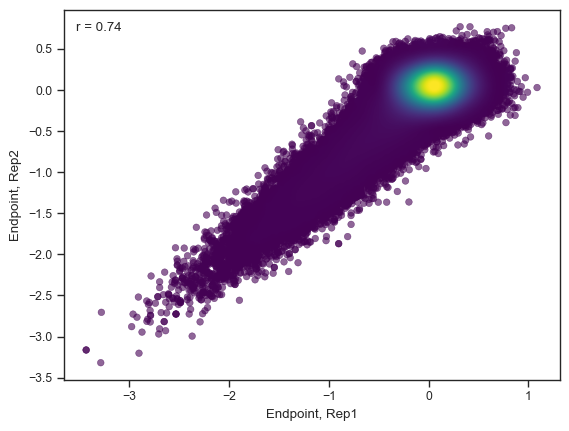

In [97]:
#check replicate correlation
gpp.point_densityplot(data = lfc_df, x = 'Endpoint, Rep1', y = 'Endpoint, Rep2')
gpp.add_correlation(data = lfc_df, x = 'Endpoint, Rep1', y = 'Endpoint, Rep2')

In [99]:
long_lfcs = (lfc_df.melt(id_vars=['gene','sgID','protospacer sequence'], value_vars = target_cols,var_name='rep', value_name='lfc'))
avg_lfcs = (long_lfcs.groupby(['gene','sgID','protospacer sequence'])
            .agg(avg_lfc = ('lfc', 'mean'),
                 n_obs = ('lfc', 'count'))
            .reset_index())
avg_lfcs['sgRNA Sequence 19bp'] = avg_lfcs['protospacer sequence'].str[1:].str.upper()
avg_lfcs

,gene,sgID,protospacer sequence,avg_lfc,n_obs,sgRNA Sequence 19bp
0,A1BG,A1BG_+_58858549.23-P1,GGCGAGGAACCGCCCAGCAA,-0.070836,2,GCGAGGAACCGCCCAGCAA
1,A1BG,A1BG_+_58858791.23-P1,GCCAGCACGCCGGCAACTAC,0.147294,2,CCAGCACGCCGGCAACTAC
2,A1BG,A1BG_+_58858964.23-P1,GCTCCGGGCGACGTGGAGTG,0.017995,2,CTCCGGGCGACGTGGAGTG
3,A1BG,A1BG_+_58864367.23-P2,GTGCTGACGGGTGACACCCA,-0.082625,2,TGCTGACGGGTGACACCCA
4,A1BG,A1BG_+_58864705.23-P2,GGGGAACAGGAGCCTTACGG,0.220517,2,GGGAACAGGAGCCTTACGG
...,...,...,...,...,...,...
208080,negative_control,non-targeting_03785,GCTACTCCGCCCCGCGGGAG,0.199671,2,CTACTCCGCCCCGCGGGAG
208081,negative_control,non-targeting_03786,GTGGCCGTTCATGGGACCGG,0.167180,2,TGGCCGTTCATGGGACCGG
208082,negative_control,non-targeting_03787,GAACTCTGTAGAAGGGACCG,-0.150735,2,AACTCTGTAGAAGGGACCG
208083,negative_control,non-targeting_03788,GCTCGACAGCGACTGAAGAG,0.073044,2,CTCGACAGCGACTGAAGAG


In [102]:
annotated_sgrna_lfcs = (avg_lfcs.merge(hCRISPRiv2_chip, how='left', on='sgRNA Sequence 19bp'))
annotated_sgrna_lfcs

,gene,sgID,protospacer sequence,avg_lfc,n_obs,sgRNA Sequence 19bp,sgRNA Sequence,Target Gene Symbol
0,A1BG,A1BG_+_58858549.23-P1,GGCGAGGAACCGCCCAGCAA,-0.070836,2,GCGAGGAACCGCCCAGCAA,NaN,NaN
1,A1BG,A1BG_+_58858791.23-P1,GCCAGCACGCCGGCAACTAC,0.147294,2,CCAGCACGCCGGCAACTAC,NaN,NaN
2,A1BG,A1BG_+_58858964.23-P1,GCTCCGGGCGACGTGGAGTG,0.017995,2,CTCCGGGCGACGTGGAGTG,NaN,NaN
3,A1BG,A1BG_+_58864367.23-P2,GTGCTGACGGGTGACACCCA,-0.082625,2,TGCTGACGGGTGACACCCA,CTGCTGACGGGTGACACCCA,A1BG
4,A1BG,A1BG_+_58864705.23-P2,GGGGAACAGGAGCCTTACGG,0.220517,2,GGGAACAGGAGCCTTACGG,CGGGAACAGGAGCCTTACGG,A1BG
...,...,...,...,...,...,...,...,...
217290,negative_control,non-targeting_03785,GCTACTCCGCCCCGCGGGAG,0.199671,2,CTACTCCGCCCCGCGGGAG,NaN,NaN
217291,negative_control,non-targeting_03786,GTGGCCGTTCATGGGACCGG,0.167180,2,TGGCCGTTCATGGGACCGG,NaN,NaN
217292,negative_control,non-targeting_03787,GAACTCTGTAGAAGGGACCG,-0.150735,2,AACTCTGTAGAAGGGACCG,NaN,NaN
217293,negative_control,non-targeting_03788,GCTCGACAGCGACTGAAGAG,0.073044,2,CTCGACAGCGACTGAAGAG,NaN,NaN


In [103]:
control_sgrna_lfcs = (annotated_sgrna_lfcs[(annotated_sgrna_lfcs['gene']
                                            .str.contains('negative_control'))]
                      .reset_index(drop=True))
control_sgrna_lfcs

,gene,sgID,protospacer sequence,avg_lfc,n_obs,sgRNA Sequence 19bp,sgRNA Sequence,Target Gene Symbol
0,negative_control,non-targeting_00000,GCTGCATGGGGCGCGAATCA,0.181798,2,CTGCATGGGGCGCGAATCA,NaN,NaN
1,negative_control,non-targeting_00001,GTGCACCCGGCTAGGACCGG,0.052273,2,TGCACCCGGCTAGGACCGG,NaN,NaN
2,negative_control,non-targeting_00002,GTGTGCAACCTCCGCCGTTG,0.002328,2,TGTGCAACCTCCGCCGTTG,NaN,NaN
3,negative_control,non-targeting_00003,GCCCGAGCAGTGGCTCGCTA,0.267769,2,CCCGAGCAGTGGCTCGCTA,NaN,NaN
4,negative_control,non-targeting_00004,GGTCAGGTAGAGGGATTGAG,0.182360,2,GTCAGGTAGAGGGATTGAG,NaN,NaN
...,...,...,...,...,...,...,...,...
3767,negative_control,non-targeting_03785,GCTACTCCGCCCCGCGGGAG,0.199671,2,CTACTCCGCCCCGCGGGAG,NaN,NaN
3768,negative_control,non-targeting_03786,GTGGCCGTTCATGGGACCGG,0.167180,2,TGGCCGTTCATGGGACCGG,NaN,NaN
3769,negative_control,non-targeting_03787,GAACTCTGTAGAAGGGACCG,-0.150735,2,AACTCTGTAGAAGGGACCG,NaN,NaN
3770,negative_control,non-targeting_03788,GCTCGACAGCGACTGAAGAG,0.073044,2,CTCGACAGCGACTGAAGAG,NaN,NaN


<Axes: xlabel='avg_lfc', ylabel='Density'>

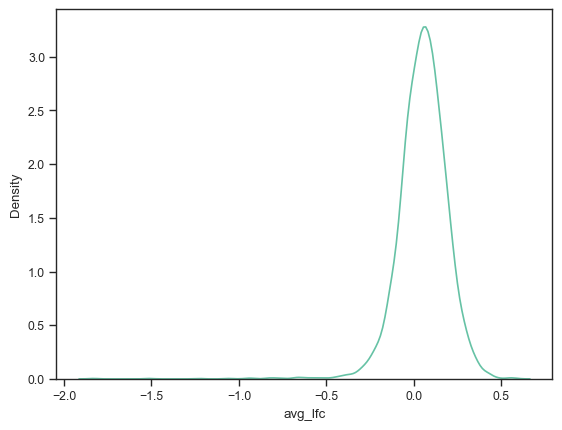

In [104]:
sns.kdeplot(x = control_sgrna_lfcs['avg_lfc'])

In [109]:
neg_ctl_mean = np.mean(control_sgrna_lfcs['avg_lfc'])
neg_ctl_sd = np.std(control_sgrna_lfcs['avg_lfc'])
zscored_sgrna_lfcs = annotated_sgrna_lfcs.copy()
zscored_sgrna_lfcs['z_scored_avg_lfc'] = ((zscored_sgrna_lfcs['avg_lfc'] - neg_ctl_mean)/neg_ctl_sd)
zscored_sgrna_lfcs = zscored_sgrna_lfcs[['sgRNA Sequence','Target Gene Symbol','avg_lfc','z_scored_avg_lfc']].drop_duplicates().dropna()
zscored_sgrna_lfcs

,sgRNA Sequence,Target Gene Symbol,avg_lfc,z_scored_avg_lfc
3,CTGCTGACGGGTGACACCCA,A1BG,-0.082625,-0.934719
4,CGGGAACAGGAGCCTTACGG,A1BG,0.220517,1.185226
11,ATCCTGTGGACAAGCCCGAG,A1BG,-0.051199,-0.714944
12,TGGACAAGCCCGAGCGGCAG,A1BG,-0.086253,-0.960085
13,GCTTGATGGCAGGTGAGTCA,A1BG,-0.231957,-1.979032
...,...,...,...,...
213512,GGACGCGGAGGAGACGACGG,ZZEF1,0.137264,0.603020
213513,CGATTCTCGCGGGACCTCGT,ZZZ3,0.112007,0.426395
213519,GCACGTATCCCGGCACCAAG,ZZZ3,-0.005225,-0.393441
213520,CACCAAGAGGCACTCGCCCC,ZZZ3,-0.060638,-0.780959


In [110]:
zip_file = ZipFile('../../Data/CRISPickRuns/sgRNA_design_9606_GRCh38_SpyoCas9_CRISPRi_RS3i-Chen2013_Ensembl_20250806.txt.zip')
crispri_genomewide_design = pd.read_table(zip_file.open('sgRNA_design_9606_GRCh38_SpyoCas9_CRISPRi_RS3i-Chen2013_Ensembl_20250806.txt'))
crispri_genomewide_design

/var/folders/mj/lhpd16ys0cx2wkbhm7s0nfcm0000gp/T/ipykernel_15119/689400535.py:2: DtypeWarning: Columns (24,25) have mixed types. Specify dtype option on import or set low_memory=False.
  crispri_genomewide_design = pd.read_table(zip_file.open('sgRNA_design_9606_GRCh38_SpyoCas9_CRISPRi_RS3i-Chen2013_Ensembl_20250806.txt'))


,Input,Quota,Target Taxon,Target Gene ID,Target Gene Symbol,Target Alias,CRISPR Mechanism,Target Domain,Reference Sequence,Strand of Target,...,Seed Score (v1),Off-Target CFD100 Hits,Off-Target Tier I CFD100 Hits,On-Target Ruleset,On-Target Efficacy Score,ATAC-seq Score,On-Target Rank,Pick Order,Picking Round,Picking Notes
0,ENSG00000000003,MAX,9606,ENSG00000000003,TSPAN6,NaN,CRISPRi,"[TSS-50,TSS+300]",NC_000023.11,-,...,0.0,0,0,RS3i-Chen2013,1.7330,0.8571,1,1.0,1.0,NaN
1,ENSG00000000003,MAX,9606,ENSG00000000003,TSPAN6,NaN,CRISPRi,"[TSS-50,TSS+300]",NC_000023.11,-,...,2.0,0,0,RS3i-Chen2013,1.6820,0.8571,2,2.0,1.0,NaN
2,ENSG00000000003,MAX,9606,ENSG00000000003,TSPAN6,NaN,CRISPRi,"[TSS-50,TSS+300]",NC_000023.11,-,...,0.0,0,0,RS3i-Chen2013,1.6170,0.8571,3,3.0,1.0,NaN
3,ENSG00000000003,MAX,9606,ENSG00000000003,TSPAN6,NaN,CRISPRi,"[TSS-50,TSS+300]",NC_000023.11,-,...,0.0,0,0,RS3i-Chen2013,1.5020,0.8571,4,4.0,1.0,NaN
4,ENSG00000000003,MAX,9606,ENSG00000000003,TSPAN6,NaN,CRISPRi,"[TSS-50,TSS+300]",NC_000023.11,-,...,0.0,0,0,RS3i-Chen2013,1.4470,0.8571,5,NaN,NaN,BsmBI:GAGACG
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1594931,ENSG00000310576,MAX,9606,ENSG00000310576,FAM174C,NaN,CRISPRi,"[TSS-50,TSS+300]",NC_000019.10,+,...,2.0,0,0,RS3i-Chen2013,-0.3301,1.0000,67,52.0,5.0,Previously skipped due to: On-Target Efficacy ...
1594932,ENSG00000310576,MAX,9606,ENSG00000310576,FAM174C,NaN,CRISPRi,"[TSS-50,TSS+300]",NC_000019.10,+,...,1.0,0,0,RS3i-Chen2013,-0.3342,1.0000,68,53.0,5.0,Previously skipped due to: On-Target Efficacy ...
1594933,ENSG00000310576,MAX,9606,ENSG00000310576,FAM174C,NaN,CRISPRi,"[TSS-50,TSS+300]",NC_000019.10,+,...,4.0,0,0,RS3i-Chen2013,-0.3360,1.0000,69,71.0,8.0,Previously skipped due to: On-Target Efficacy ...
1594934,ENSG00000310576,MAX,9606,ENSG00000310576,FAM174C,NaN,CRISPRi,"[TSS-50,TSS+300]",NC_000019.10,+,...,2.0,0,0,RS3i-Chen2013,-0.4603,1.0000,70,54.0,5.0,Previously skipped due to: On-Target Efficacy ...


In [113]:
#merge with genome wide crispick design run to get TSS offset, ATAC-seq overlap
merged_sgrna_design = zscored_sgrna_lfcs.merge(crispri_genomewide_design,
                                                 left_on = ['sgRNA Sequence','Target Gene Symbol'],
                                                 right_on = ['sgRNA Sequence','Target Gene Symbol'],
                                                 how = 'inner').reset_index(drop=True)
merged_sgrna_design

,sgRNA Sequence,Target Gene Symbol,avg_lfc,z_scored_avg_lfc,Input,Quota,Target Taxon,Target Gene ID,Target Alias,CRISPR Mechanism,...,Seed Score (v1),Off-Target CFD100 Hits,Off-Target Tier I CFD100 Hits,On-Target Ruleset,On-Target Efficacy Score,ATAC-seq Score,On-Target Rank,Pick Order,Picking Round,Picking Notes
0,TTCTGTAGACTTACCACGGA,A1CF,-0.075804,-0.887018,ENSG00000148584,MAX,9606,ENSG00000148584,NaN,CRISPRi,...,1.0,0,0,RS3i-Chen2013,-0.440300,0.1429,26,20.0,5.0,Previously skipped due to: On-Target Efficacy ...
1,GGGGATCTCTGAAATTACTC,A1CF,-0.162672,-1.494506,ENSG00000148584,MAX,9606,ENSG00000148584,NaN,CRISPRi,...,0.0,0,0,RS3i-Chen2013,1.727000,0.1429,1,1.0,1.0,NaN
2,AAGGAAACCTTTTCCGGGTG,A1CF,0.020406,-0.214195,ENSG00000148584,MAX,9606,ENSG00000148584,NaN,CRISPRi,...,2.0,0,0,RS3i-Chen2013,-0.000687,0.1429,21,NaN,NaN,On-Target Efficacy Score < 1.2; poly(T):TTTT
3,CGTTGAATTCGCCATAATCA,A1CF,-0.004960,-0.391589,ENSG00000148584,MAX,9606,ENSG00000148584,NaN,CRISPRi,...,0.0,0,0,RS3i-Chen2013,0.103300,0.1429,19,16.0,5.0,Previously skipped due to: On-Target Efficacy ...
4,TTAGGCTCGATAACAGAAGA,A1CF,-0.046153,-0.679662,ENSG00000148584,MAX,9606,ENSG00000148584,NaN,CRISPRi,...,0.0,0,0,RS3i-Chen2013,0.706500,0.0000,5,5.0,5.0,Previously skipped due to: On-Target Efficacy ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106685,TGTCGGAGGTTGACAGGTCG,ZZEF1,0.104115,0.371199,ENSG00000074755,MAX,9606,ENSG00000074755,NaN,CRISPRi,...,1.0,0,0,RS3i-Chen2013,0.946900,1.0000,24,18.0,5.0,Previously skipped due to: On-Target Efficacy ...
106686,AGCTGCTGTCGGAGGTTGAC,ZZEF1,0.272900,1.551560,ENSG00000074755,MAX,9606,ENSG00000074755,NaN,CRISPRi,...,2.0,0,0,RS3i-Chen2013,1.479000,1.0000,9,9.0,2.0,Previously skipped due to: Ancestry variant fr...
106687,CGCCCGCCAGCTGCTGTCGG,ZZEF1,-0.006861,-0.404878,ENSG00000074755,MAX,9606,ENSG00000074755,NaN,CRISPRi,...,1.0,0,0,RS3i-Chen2013,1.299000,1.0000,13,11.0,2.0,Previously skipped due to: Ancestry variant fr...
106688,CAACCTCCGACAGCAGCTGG,ZZEF1,0.214698,1.144538,ENSG00000074755,MAX,9606,ENSG00000074755,NaN,CRISPRi,...,1.0,0,0,RS3i-Chen2013,2.097000,1.0000,1,6.0,2.0,Previously skipped due to: Ancestry variant fr...


### Format for RS3i Validation

In [115]:
rs3i_input = merged_sgrna_design[['sgRNA Context Sequence','z_scored_avg_lfc','Target Gene Symbol','sgRNA \'Cut\' Site TSS Offset','ATAC-seq Score']].drop_duplicates()
rs3i_input

,sgRNA Context Sequence,z_scored_avg_lfc,Target Gene Symbol,sgRNA 'Cut' Site TSS Offset,ATAC-seq Score
0,AAATTTCTGTAGACTTACCACGGAGGGTTC,-0.887018,A1CF,290,0.1429
1,GGGTGGGGATCTCTGAAATTACTCAGGTAT,-1.494506,A1CF,42,0.1429
2,AATCAAGGAAACCTTTTCCGGGTGGGGATC,-0.214195,A1CF,23,0.1429
3,GACACGTTGAATTCGCCATAATCAAGGAAA,-0.391589,A1CF,4,0.1429
4,TGAATTAGGCTCGATAACAGAAGAGGGTAA,-0.679662,A1CF,143,0.0000
...,...,...,...,...,...
106685,CTGCTGTCGGAGGTTGACAGGTCGAGGCGG,0.371199,ZZEF1,60,1.0000
106686,CGCCAGCTGCTGTCGGAGGTTGACAGGTCG,1.551560,ZZEF1,54,1.0000
106687,TCCCCGCCCGCCAGCTGCTGTCGGAGGTTG,-0.404878,ZZEF1,46,1.0000
106688,CTGTCAACCTCCGACAGCAGCTGGCGGGCG,1.144538,ZZEF1,38,1.0000


In [126]:
essential_genes = pd.read_csv('../../Data/essentialNonessentialAnnotations/AchillesCommonEssentialControls.csv').Gene
essential_gene_ids = essential_genes.str.split('(',expand=True)[0].str.strip()
essential_gene_ids

0           AAMP
1          AARS1
2       AASDHPPT
3          ABCB7
4          ABCE1
          ...   
1242      ZNF407
1243      ZNF574
1244      ZNF622
1245      ZNHIT6
1246        ZZZ3
Name: 0, Length: 1247, dtype: object

In [128]:
hcrispriv2_ess = rs3i_input[rs3i_input['Target Gene Symbol'].isin(essential_gene_ids)].reset_index(drop=True)
hcrispriv2_ess['rs3ChenSeqScore'] = predict_seq(hcrispriv2_ess['sgRNA Context Sequence'], sequence_tracr='Chen2013')
hcrispriv2_ess

Calculating sequence-based features


100%|██████████████████████████████████████| 8341/8341 [00:13<00:00, 622.53it/s]


,sgRNA Context Sequence,z_scored_avg_lfc,Target Gene Symbol,sgRNA 'Cut' Site TSS Offset,ATAC-seq Score,rs3ChenSeqScore
0,GCAGAGCTGACTCTGGGAGGCGTTTGGGCC,-7.742423,AAMP,13,1.0,-0.681281
1,GCGTCGTCGCGCAGAGCTGACTCTGGGAGG,-7.923226,AAMP,3,1.0,0.155863
2,GTAGGCCGCCCTCGGAGAGCTCTGCGGTGC,-4.952999,AARS1,107,1.0,0.221997
3,GGGGACGGCGACCCTAGGAGAGGTAGGCCG,-10.701140,AARS1,85,1.0,0.521904
4,AGCTGGGGACGGCGACCCTAGGAGAGGTAG,-15.828561,AARS1,81,1.0,0.324857
...,...,...,...,...,...,...
8336,TTGGCTCCACACGTGGGCCGCCGTAGGTAT,-4.102627,ZNHIT6,40,1.0,0.346428
8337,TTGTGGCTGCTTGGCTCCACACGTGGGCCG,-8.282201,ZNHIT6,30,1.0,0.342999
8338,ATGTGGCTGCTGCACACCAATAGGAGGAAT,-7.823945,ZNHIT6,69,1.0,0.046308
8339,AGGAATTACCGGTCGGAATACCTACGGCGG,-14.490401,ZNHIT6,45,1.0,1.066892


In [129]:
#remove overlapping genes
overlapping_genes = pd.read_csv('../../Data/geneOverlap/GW_ensembl_protein_coding_df_1kb.csv')
overlapping_gene_2_3 = overlapping_genes[overlapping_genes['overlap type'].isin([2,3])]
gene_2_3_unique = set(list(overlapping_gene_2_3['Selected Gene name']) +\
list(overlapping_gene_2_3['Overlapping Gene name']))
hcrispriv2_ess_nonoverlapping = hcrispriv2_ess[~hcrispriv2_ess['Target Gene Symbol'].isin(gene_2_3_unique)]
hcrispriv2_ess_nonoverlapping

,sgRNA Context Sequence,z_scored_avg_lfc,Target Gene Symbol,sgRNA 'Cut' Site TSS Offset,ATAC-seq Score,rs3ChenSeqScore
11,GAAAGCGGACCTCGCCGCTATCTCGGGCCT,-1.092781,AASDHPPT,22,1.0,-0.478318
12,TGGATGGCACCAAGCAGAACCGTTTGGCAG,-2.758420,AASDHPPT,67,1.0,0.683108
13,GGCCCAGCGCACGCCCTCCATGGATGGCAC,-1.632339,AASDHPPT,87,1.0,0.634648
14,TGCGCACGGACGCCGGGAAGAAGGGGGTGG,-2.460856,AASDHPPT,-20,1.0,0.374179
15,TCCGCGCCATCAGGCCCGAGATAGCGGCGA,-5.028847,AASDHPPT,23,1.0,-0.165474
...,...,...,...,...,...,...
8336,TTGGCTCCACACGTGGGCCGCCGTAGGTAT,-4.102627,ZNHIT6,40,1.0,0.346428
8337,TTGTGGCTGCTTGGCTCCACACGTGGGCCG,-8.282201,ZNHIT6,30,1.0,0.342999
8338,ATGTGGCTGCTGCACACCAATAGGAGGAAT,-7.823945,ZNHIT6,69,1.0,0.046308
8339,AGGAATTACCGGTCGGAATACCTACGGCGG,-14.490401,ZNHIT6,45,1.0,1.066892


In [131]:
X_test = hcrispriv2_ess_nonoverlapping[['Target Gene Symbol','sgRNA Context Sequence','sgRNA \'Cut\' Site TSS Offset', 'rs3ChenSeqScore','z_scored_avg_lfc']].copy()
X_test.loc[:,'rs3ChenSeqScore'] = round(X_test['rs3ChenSeqScore'],4)
X_test.loc[:,'sgRNA \'Cut\' Site TSS Offset'] = X_test['sgRNA \'Cut\' Site TSS Offset'].astype(int)
X_test['ATAC_overlap_with_peak'] = pd.cut(hcrispriv2_ess['ATAC-seq Score'],bins=[0,0.5,1,np.inf],right=False)

# one-hot encoding
X_test_encoded = pd.get_dummies(X_test, columns=['ATAC_overlap_with_peak'])

bool_cols = X_test_encoded.select_dtypes(include=['bool']).columns.tolist()
X_test_encoded[bool_cols] = X_test_encoded[bool_cols].astype(int)

def clean_column_name(name):
    return (
        str(name)
        .replace('[', '_')
        .replace(']', '_')
        .replace('<', '_')
        .replace('>', '_')
        .replace(' ', '_')
        .replace(',', '_')
        .replace('(', '_')
        .replace(')', '_')
    )

X_test_encoded.columns = [clean_column_name(col) for col in X_test_encoded.columns]
X_test_encoded

,Target_Gene_Symbol,sgRNA_Context_Sequence,sgRNA_'Cut'_Site_TSS_Offset,rs3ChenSeqScore,z_scored_avg_lfc,ATAC_overlap_with_peak__0.0__0.5_,ATAC_overlap_with_peak__0.5__1.0_,ATAC_overlap_with_peak__1.0__inf_
11,AASDHPPT,GAAAGCGGACCTCGCCGCTATCTCGGGCCT,22,-0.4783,-1.092781,0,0,1
12,AASDHPPT,TGGATGGCACCAAGCAGAACCGTTTGGCAG,67,0.6831,-2.758420,0,0,1
13,AASDHPPT,GGCCCAGCGCACGCCCTCCATGGATGGCAC,87,0.6346,-1.632339,0,0,1
14,AASDHPPT,TGCGCACGGACGCCGGGAAGAAGGGGGTGG,-20,0.3742,-2.460856,0,0,1
15,AASDHPPT,TCCGCGCCATCAGGCCCGAGATAGCGGCGA,23,-0.1655,-5.028847,0,0,1
...,...,...,...,...,...,...,...,...
8336,ZNHIT6,TTGGCTCCACACGTGGGCCGCCGTAGGTAT,40,0.3464,-4.102627,0,0,1
8337,ZNHIT6,TTGTGGCTGCTTGGCTCCACACGTGGGCCG,30,0.3430,-8.282201,0,0,1
8338,ZNHIT6,ATGTGGCTGCTGCACACCAATAGGAGGAAT,69,0.0463,-7.823945,0,0,1
8339,ZNHIT6,AGGAATTACCGGTCGGAATACCTACGGCGG,45,1.0669,-14.490401,0,0,1


In [132]:
X_test_encoded.to_csv('../../Data/externalData/hCRISPRiv2/hcrispriv2_rs3i_input.csv',index=False)

### Format for Seed Score Validation

In [134]:
nonessential_genes = pd.read_csv('../../Data/essentialNonessentialAnnotations/AchillesNonessentialControls.csv').Gene
nonessential_gene_ids = nonessential_genes.str.split('(',expand=True)[0].str.strip()
nonessential_gene_ids

0        ABCG8
1        ACCSL
2       ACTL7A
3       ACTL7B
4        ACTL9
        ...   
776    ZNF804B
777      ZNRF4
778        ZP2
779        ZP4
780     ZSWIM2
Name: 0, Length: 781, dtype: object

In [135]:
seed_score_input = merged_sgrna_design[['sgRNA Sequence','sgRNA Context Sequence','z_scored_avg_lfc','Target Gene Symbol']].drop_duplicates()
seed_score_input

,sgRNA Sequence,sgRNA Context Sequence,z_scored_avg_lfc,Target Gene Symbol
0,TTCTGTAGACTTACCACGGA,AAATTTCTGTAGACTTACCACGGAGGGTTC,-0.887018,A1CF
1,GGGGATCTCTGAAATTACTC,GGGTGGGGATCTCTGAAATTACTCAGGTAT,-1.494506,A1CF
2,AAGGAAACCTTTTCCGGGTG,AATCAAGGAAACCTTTTCCGGGTGGGGATC,-0.214195,A1CF
3,CGTTGAATTCGCCATAATCA,GACACGTTGAATTCGCCATAATCAAGGAAA,-0.391589,A1CF
4,TTAGGCTCGATAACAGAAGA,TGAATTAGGCTCGATAACAGAAGAGGGTAA,-0.679662,A1CF
...,...,...,...,...
106685,TGTCGGAGGTTGACAGGTCG,CTGCTGTCGGAGGTTGACAGGTCGAGGCGG,0.371199,ZZEF1
106686,AGCTGCTGTCGGAGGTTGAC,CGCCAGCTGCTGTCGGAGGTTGACAGGTCG,1.551560,ZZEF1
106687,CGCCCGCCAGCTGCTGTCGG,TCCCCGCCCGCCAGCTGCTGTCGGAGGTTG,-0.404878,ZZEF1
106688,CAACCTCCGACAGCAGCTGG,CTGTCAACCTCCGACAGCAGCTGGCGGGCG,1.144538,ZZEF1


In [136]:
hcrispriv2_noness = seed_score_input[seed_score_input['Target Gene Symbol'].isin(nonessential_gene_ids)].reset_index(drop=True)
hcrispriv2_noness

,sgRNA Sequence,sgRNA Context Sequence,z_scored_avg_lfc,Target Gene Symbol
0,GCCCACAGGTCTGTGACCCT,TGGGGCCCACAGGTCTGTGACCCTGGGCTG,0.327619,ABCG8
1,TTCCCGGCCATGGGGCCCAC,CGCCTTCCCGGCCATGGGGCCCACAGGTCT,0.556994,ABCG8
2,TCACTCACCGAGGTATCCTG,TTGCTCACTCACCGAGGTATCCTGGGGAGT,-1.527781,ABCG8
3,CTAGGACAGAAGGCTCCTGA,GGTGCTAGGACAGAAGGCTCCTGAGGGAAG,-0.623116,ABCG8
4,CCGGGTGGTGCTAGGACAGA,ATGTCCGGGTGGTGCTAGGACAGAAGGCTC,-0.057151,ABCG8
...,...,...,...,...
4006,TGGCCAACTGGGGGCGGTAG,ATGATGGCCAACTGGGGGCGGTAGGGGCGG,-0.553084,ZSWIM2
4007,TAGCCTCGGCGAAGCATGCT,CTTATAGCCTCGGCGAAGCATGCTGGGTGC,0.164902,ZSWIM2
4008,TCGGCGAAGCATGCTGGGTG,AGCCTCGGCGAAGCATGCTGGGTGCGGGCG,0.841992,ZSWIM2
4009,CCCCTCTGCTCGGCTCACTG,GCGGCCCCTCTGCTCGGCTCACTGAGGCGC,-0.302382,ZSWIM2


In [137]:
#remove overlapping genes
overlapping_genes = pd.read_csv('../../Data/geneOverlap/GW_ensembl_protein_coding_df_1kb.csv')
overlapping_gene_2_3 = overlapping_genes[overlapping_genes['overlap type'].isin([2,3])]
gene_2_3_unique = set(list(overlapping_gene_2_3['Selected Gene name']) +\
list(overlapping_gene_2_3['Overlapping Gene name']))
hcrispriv2_noness_nonoverlapping = hcrispriv2_noness[~hcrispriv2_noness['Target Gene Symbol'].isin(gene_2_3_unique)]
hcrispriv2_noness_nonoverlapping

,sgRNA Sequence,sgRNA Context Sequence,z_scored_avg_lfc,Target Gene Symbol
0,GCCCACAGGTCTGTGACCCT,TGGGGCCCACAGGTCTGTGACCCTGGGCTG,0.327619,ABCG8
1,TTCCCGGCCATGGGGCCCAC,CGCCTTCCCGGCCATGGGGCCCACAGGTCT,0.556994,ABCG8
2,TCACTCACCGAGGTATCCTG,TTGCTCACTCACCGAGGTATCCTGGGGAGT,-1.527781,ABCG8
3,CTAGGACAGAAGGCTCCTGA,GGTGCTAGGACAGAAGGCTCCTGAGGGAAG,-0.623116,ABCG8
4,CCGGGTGGTGCTAGGACAGA,ATGTCCGGGTGGTGCTAGGACAGAAGGCTC,-0.057151,ABCG8
...,...,...,...,...
4006,TGGCCAACTGGGGGCGGTAG,ATGATGGCCAACTGGGGGCGGTAGGGGCGG,-0.553084,ZSWIM2
4007,TAGCCTCGGCGAAGCATGCT,CTTATAGCCTCGGCGAAGCATGCTGGGTGC,0.164902,ZSWIM2
4008,TCGGCGAAGCATGCTGGGTG,AGCCTCGGCGAAGCATGCTGGGTGCGGGCG,0.841992,ZSWIM2
4009,CCCCTCTGCTCGGCTCACTG,GCGGCCCCTCTGCTCGGCTCACTGAGGCGC,-0.302382,ZSWIM2


In [138]:
#remove low RS3 Sequence score guides
hcrispriv2_noness_nonoverlapping['rs3ChenSeqScore'] = predict_seq(hcrispriv2_noness_nonoverlapping['sgRNA Context Sequence'], sequence_tracr='Chen2013')
hcrispriv2_noness_nonoverlapping_active = hcrispriv2_noness_nonoverlapping[hcrispriv2_noness_nonoverlapping['rs3ChenSeqScore'] > -0.5].copy()
hcrispriv2_noness_nonoverlapping_active

Calculating sequence-based features


100%|██████████████████████████████████████| 3904/3904 [00:06<00:00, 592.13it/s]
/var/folders/mj/lhpd16ys0cx2wkbhm7s0nfcm0000gp/T/ipykernel_15119/2603486279.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hcrispriv2_noness_nonoverlapping['rs3ChenSeqScore'] = predict_seq(hcrispriv2_noness_nonoverlapping['sgRNA Context Sequence'], sequence_tracr='Chen2013')


,sgRNA Sequence,sgRNA Context Sequence,z_scored_avg_lfc,Target Gene Symbol,rs3ChenSeqScore
0,GCCCACAGGTCTGTGACCCT,TGGGGCCCACAGGTCTGTGACCCTGGGCTG,0.327619,ABCG8,0.226611
1,TTCCCGGCCATGGGGCCCAC,CGCCTTCCCGGCCATGGGGCCCACAGGTCT,0.556994,ABCG8,-0.344169
2,TCACTCACCGAGGTATCCTG,TTGCTCACTCACCGAGGTATCCTGGGGAGT,-1.527781,ABCG8,1.019995
3,CTAGGACAGAAGGCTCCTGA,GGTGCTAGGACAGAAGGCTCCTGAGGGAAG,-0.623116,ABCG8,0.537225
4,CCGGGTGGTGCTAGGACAGA,ATGTCCGGGTGGTGCTAGGACAGAAGGCTC,-0.057151,ABCG8,0.267031
...,...,...,...,...,...
4005,CACATTGGGTATGCCAGTGG,TACGCACATTGGGTATGCCAGTGGGGGAAC,-0.520459,ZSWIM2,0.483515
4007,TAGCCTCGGCGAAGCATGCT,CTTATAGCCTCGGCGAAGCATGCTGGGTGC,0.164902,ZSWIM2,0.419896
4008,TCGGCGAAGCATGCTGGGTG,AGCCTCGGCGAAGCATGCTGGGTGCGGGCG,0.841992,ZSWIM2,-0.434224
4009,CCCCTCTGCTCGGCTCACTG,GCGGCCCCTCTGCTCGGCTCACTGAGGCGC,-0.302382,ZSWIM2,0.056750


In [140]:
#remove genes that don't behave as nonessential
hcrispriv2_noness_nonoverlapping_active['gene_avg_zscore'] = hcrispriv2_noness_nonoverlapping_active.groupby('Target Gene Symbol')['z_scored_avg_lfc'].transform('mean')
hcrispriv2_noness_nonoverlapping_active = hcrispriv2_noness_nonoverlapping_active[hcrispriv2_noness_nonoverlapping_active['gene_avg_zscore'] > -2].copy()
hcrispriv2_noness_nonoverlapping_active

,sgRNA Sequence,sgRNA Context Sequence,z_scored_avg_lfc,Target Gene Symbol,rs3ChenSeqScore,gene_avg_zscore
0,GCCCACAGGTCTGTGACCCT,TGGGGCCCACAGGTCTGTGACCCTGGGCTG,0.327619,ABCG8,0.226611,-0.264203
1,TTCCCGGCCATGGGGCCCAC,CGCCTTCCCGGCCATGGGGCCCACAGGTCT,0.556994,ABCG8,-0.344169,-0.264203
2,TCACTCACCGAGGTATCCTG,TTGCTCACTCACCGAGGTATCCTGGGGAGT,-1.527781,ABCG8,1.019995,-0.264203
3,CTAGGACAGAAGGCTCCTGA,GGTGCTAGGACAGAAGGCTCCTGAGGGAAG,-0.623116,ABCG8,0.537225,-0.264203
4,CCGGGTGGTGCTAGGACAGA,ATGTCCGGGTGGTGCTAGGACAGAAGGCTC,-0.057151,ABCG8,0.267031,-0.264203
...,...,...,...,...,...,...
4005,CACATTGGGTATGCCAGTGG,TACGCACATTGGGTATGCCAGTGGGGGAAC,-0.520459,ZSWIM2,0.483515,-0.243648
4007,TAGCCTCGGCGAAGCATGCT,CTTATAGCCTCGGCGAAGCATGCTGGGTGC,0.164902,ZSWIM2,0.419896,-0.243648
4008,TCGGCGAAGCATGCTGGGTG,AGCCTCGGCGAAGCATGCTGGGTGCGGGCG,0.841992,ZSWIM2,-0.434224,-0.243648
4009,CCCCTCTGCTCGGCTCACTG,GCGGCCCCTCTGCTCGGCTCACTGAGGCGC,-0.302382,ZSWIM2,0.056750,-0.243648


In [141]:
hcrispriv2_noness_nonoverlapping_active['promiscuous'] = hcrispriv2_noness_nonoverlapping_active['z_scored_avg_lfc'] < -3
hcrispriv2_noness_nonoverlapping_active['nonpromiscuous'] = hcrispriv2_noness_nonoverlapping_active['z_scored_avg_lfc'] > -1
hcrispriv2_noness_labeled = hcrispriv2_noness_nonoverlapping_active[hcrispriv2_noness_nonoverlapping_active['promiscuous'] | hcrispriv2_noness_nonoverlapping_active['nonpromiscuous']].copy()
hcrispriv2_noness_labeled

,sgRNA Sequence,sgRNA Context Sequence,z_scored_avg_lfc,Target Gene Symbol,rs3ChenSeqScore,gene_avg_zscore,promiscuous,nonpromiscuous
0,GCCCACAGGTCTGTGACCCT,TGGGGCCCACAGGTCTGTGACCCTGGGCTG,0.327619,ABCG8,0.226611,-0.264203,False,True
1,TTCCCGGCCATGGGGCCCAC,CGCCTTCCCGGCCATGGGGCCCACAGGTCT,0.556994,ABCG8,-0.344169,-0.264203,False,True
3,CTAGGACAGAAGGCTCCTGA,GGTGCTAGGACAGAAGGCTCCTGAGGGAAG,-0.623116,ABCG8,0.537225,-0.264203,False,True
4,CCGGGTGGTGCTAGGACAGA,ATGTCCGGGTGGTGCTAGGACAGAAGGCTC,-0.057151,ABCG8,0.267031,-0.264203,False,True
5,TCTAAGAGAGCTGCAGCCCA,TGGGTCTAAGAGAGCTGCAGCCCAGGGTCA,0.255273,ABCG8,1.061433,-0.264203,False,True
...,...,...,...,...,...,...,...,...
4004,CGCCTCAGTGAGCCGAGCAG,CTGGCGCCTCAGTGAGCCGAGCAGAGGGGC,0.634663,ZSWIM2,-0.088560,-0.243648,False,True
4005,CACATTGGGTATGCCAGTGG,TACGCACATTGGGTATGCCAGTGGGGGAAC,-0.520459,ZSWIM2,0.483515,-0.243648,False,True
4007,TAGCCTCGGCGAAGCATGCT,CTTATAGCCTCGGCGAAGCATGCTGGGTGC,0.164902,ZSWIM2,0.419896,-0.243648,False,True
4008,TCGGCGAAGCATGCTGGGTG,AGCCTCGGCGAAGCATGCTGGGTGCGGGCG,0.841992,ZSWIM2,-0.434224,-0.243648,False,True


In [142]:
hcrispriv2_noness_labeled.to_csv('../../Data/externalData/hCRISPRiv2/hcrispriv2_seed_score_validation_input.csv',index=False)